<div style="background-color:#000047; padding: 30px; border-radius: 10px; color: white; text-align: center;">
    <img src='Figures/alinco.png' style="height: 100px; margin-bottom: 10px;"/>
    <h1>Aprendizaje Automático Avanzado</h1>
    <h3>Ejemplo Gaussian Mixture Models</h3>
</div>

<div style="background-color:#e6f2ff; padding:20px; border-radius:10px;">
<img style="float:left; margin-right:20px;" src='Figures/alinco.png' width="120"/>
<h1 style="color:#000047;">Actividad 2: Clustering por Gaussian Mixture Models</h1>
<br style="clear:both"/>
</div>

<div style="border-left:4px solid #000047; padding:10px; margin-top:10px; background:#f5f5f5;">
<b>Objetivo:</b> En esta actividad construiras un clustering basado en GMM. 
</div>

<div style="margin-top:10px;">
<b>Instrucciones generales: leea y responda los siguientes incisos</b>
<ul>
</ul>
</div>

**1.** Utilice GMM para la segmentación de clientes en el análisis de la cesta de la compra del siguiente dataset `customer_shopping.csv`. Emplee GMM para agrupar a los clientes según su comportamiento de compra. Una vez agrupados, podrá crear promociones dirigidas y recomendaciones personalizadas para cada segmento.

In [3]:
import os
os.environ["OMP_NUM_THREADS"] = "1"  

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [4]:
#Cargamos el dataset
df = pd.read_csv("C:/Users/x/OneDrive - MBGE INTERSISTEMAS/MBGE/DIT/IA/Maestria/Aprendizaje_Automatico_Avanzado_2026/Introducción/data/customer_shopping.csv")
df.head()

,Customer,Bread,Milk,Eggs,Beer,Chips
0,c001,12,10,8,0,1
1,c002,10,8,7,1,0
2,c003,11,9,6,0,1
3,c004,1,2,1,10,8
4,c005,0,1,2,12,10


In [5]:
df.isnull().sum()

Customer    0
Bread       0
Milk        0
Eggs        0
Beer        0
Chips       0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Customer  84 non-null     object
 1   Bread     84 non-null     int64 
 2   Milk      84 non-null     int64 
 3   Eggs      84 non-null     int64 
 4   Beer      84 non-null     int64 
 5   Chips     84 non-null     int64 
dtypes: int64(5), object(1)
memory usage: 4.1+ KB


In [7]:
df.set_index('Customer', inplace=True)
df.head()

,Bread,Milk,Eggs,Beer,Chips
Customer,,,,,
c001,12,10,8,0,1
c002,10,8,7,1,0
c003,11,9,6,0,1
c004,1,2,1,10,8
c005,0,1,2,12,10


In [8]:
df.describe()

,Bread,Milk,Eggs,Beer,Chips
count,84.000000,84.000000,84.000000,84.000000,84.000000
mean,6.297619,5.297619,4.142857,5.333333,4.630952
std,4.976523,3.731274,3.089597,4.616193,3.892470
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,1.000000,1.000000,1.000000
50%,5.000000,5.000000,4.000000,4.000000,4.000000
75%,11.000000,9.000000,7.000000,10.000000,8.000000
max,15.000000,12.000000,10.000000,14.000000,12.000000


In [9]:
# Escalamiento y selección de características, utilice las columnas 'Bread', 'Milk', 'Eggs', 'Beer', 'Chips'
from sklearn.preprocessing import StandardScaler

scale = StandardScaler()
df_scale = pd.DataFrame(scale.fit_transform(df), columns=df.columns)
df_scale

,Bread,Milk,Eggs,Beer,Chips
0,1.152739,1.267831,1.255927,-1.162292,-0.938417
1,0.748438,0.728601,0.930316,-0.944363,-1.196866
2,0.950588,0.998216,0.604706,-1.162292,-0.938417
3,-1.070916,-0.889086,-1.023348,1.017006,0.870728
4,-1.273066,-1.158701,-0.697737,1.452865,1.387627
...,...,...,...,...,...
79,1.759190,1.537445,1.255927,-0.944363,-0.938417
80,-1.070916,-1.428316,-1.023348,0.799076,0.353829
81,-0.262314,-0.349857,-0.697737,-0.290573,-0.421519
82,1.152739,1.267831,0.604706,-0.944363,-0.938417


In [10]:
# Obtenemos valores de X
X = df[['Bread', 'Milk', 'Eggs', 'Beer', 'Chips']]
X.values

array([[12, 10,  8,  0,  1],
       [10,  8,  7,  1,  0],
       [11,  9,  6,  0,  1],
       [ 1,  2,  1, 10,  8],
       [ 0,  1,  2, 12, 10],
       [ 2,  1,  0,  9,  7],
       [ 6,  5,  4,  4,  3],
       [ 5,  6,  5,  5,  4],
       [14, 11,  9,  1,  0],
       [ 2,  0,  2, 11,  7],
       [11,  8,  7,  2,  0],
       [ 5,  7,  4,  4,  4],
       [12, 12,  8,  0,  1],
       [ 1,  3,  1, 13, 11],
       [ 9, 10,  7,  0,  2],
       [ 3,  0,  0, 14,  8],
       [15,  7,  5,  1,  1],
       [ 6,  4,  2,  6,  3],
       [10,  9,  9,  0,  0],
       [ 1,  1,  1, 10,  7],
       [13, 10,  6,  2,  2],
       [ 4,  6,  3,  5,  5],
       [ 1,  1,  2, 12,  9],
       [11,  8, 10,  2,  1],
       [ 1,  3,  2, 10, 11],
       [ 5,  4,  5,  3,  5],
       [ 0,  1,  0, 14,  8],
       [12, 11,  6,  1,  2],
       [ 2,  2,  2, 13,  6],
       [ 4,  3,  6,  3,  4],
       [11, 12,  6,  1,  0],
       [15,  9,  6,  1,  1],
       [ 0,  0,  2, 14,  9],
       [ 6,  7,  4,  4,  5],
       [ 3,  2

In [11]:
from sklearn.mixture import GaussianMixture

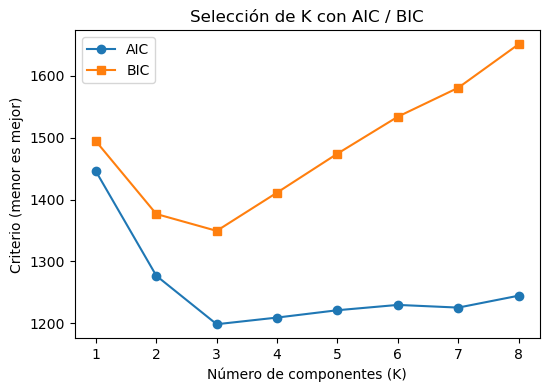

In [12]:
# Entrenar el modelo por GMM utilizando métricas para saber cuantos componentes elegir.
ks = range(1, 9)
aics, bics = [], []
for k in ks:
    g = GaussianMixture(n_components=k, covariance_type='full', random_state=42).fit(X)
    aics.append(g.aic(X))
    bics.append(g.bic(X))

plt.figure(figsize=(6, 4))
plt.plot(ks, aics, 'o-', label='AIC')
plt.plot(ks, bics, 's-', label='BIC')
plt.xlabel('Número de componentes (K)')
plt.ylabel('Criterio (menor es mejor)')
plt.title('Selección de K con AIC / BIC')
plt.legend()
plt.show()

In [13]:
# Entrene el modelo por GMM utilizando el K elegido con las métricas anteriores

gmm_shopping = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
gmm_shopping.fit(X)

,n_components,3
,covariance_type,'full'
,tol,0.001
,reg_covar,1e-06
,max_iter,100
,n_init,1
,init_params,'kmeans'
,weights_init,None
,means_init,None
,precisions_init,None
,random_state,42


In [14]:

# asignación dura (cluster más probable)
predicciones = gmm_shopping.predict(X)

# asignación suave (probabilidades de pertenencia)
responsabilidades = gmm_shopping.predict_proba(X)

print(f"Modelo entrenado con K = 3 componentes")
#print(f"Convergió: {gmm.converged_} en {gmm.n_iter_} iteraciones")


Modelo entrenado con K = 3 componentes


In [15]:
responsabilidades

array([[1.00000000e+000, 7.93852253e-073, 2.37676074e-023],
       [1.00000000e+000, 3.04125433e-050, 8.52048010e-014],
       [1.00000000e+000, 7.53851579e-053, 4.71254437e-017],
       [2.25752776e-115, 1.00000000e+000, 3.58784933e-021],
       [6.89364167e-160, 1.00000000e+000, 8.32209843e-037],
       [2.38151927e-097, 1.00000000e+000, 9.62753754e-016],
       [3.82988731e-019, 1.85060090e-015, 1.00000000e+000],
       [1.58554949e-026, 1.51906572e-016, 1.00000000e+000],
       [1.00000000e+000, 5.63275815e-095, 8.07686953e-032],
       [2.03216173e-113, 1.00000000e+000, 2.17614062e-021],
       [1.00000000e+000, 3.75320601e-054, 5.16793242e-014],
       [7.79260924e-023, 9.21359935e-017, 1.00000000e+000],
       [1.00000000e+000, 5.41852062e-080, 9.71327790e-026],
       [8.06449856e-182, 1.00000000e+000, 6.92006385e-043],
       [1.00000000e+000, 1.11881494e-050, 1.71138418e-012],
       [1.26261451e-161, 1.00000000e+000, 6.14924522e-036],
       [1.00000000e+000, 2.59511680e-066

In [16]:
predicciones

array([0, 0, 0, 1, 1, 1, 2, 2, 0, 1, 0, 2, 0, 1, 0, 1, 0, 2, 0, 1, 0, 2,
       1, 0, 1, 2, 1, 0, 1, 2, 0, 0, 1, 2, 1, 0, 1, 2, 0, 0, 1, 2, 1, 0,
       1, 2, 1, 0, 1, 2, 0, 0, 1, 2, 1, 0, 1, 2, 1, 0, 1, 2, 0, 0, 1, 2,
       1, 0, 1, 2, 0, 0, 1, 2, 1, 0, 1, 2, 1, 0, 1, 2, 0, 0], dtype=int64)

In [17]:
# Muestre el perfil de los clusters

# Aplicamos PCA para poder ver los datos en 2 dimensiones (n_components)
from sklearn.decomposition import PCA

pca_shopping = PCA(n_components = 2)
X_pca_shopping = pca_shopping.fit_transform(X)
df_pca_shopping = pd.DataFrame(X_pca_shopping, columns = ['componente_1', 'componente2'])
df_pca_shopping

,componente_1,componente2
0,10.494026,0.203188
1,8.180932,-1.096564
2,8.894879,-0.491213
3,-9.026416,-0.322553
4,-11.504635,0.555730
...,...,...
79,12.029193,3.103425
80,-8.487016,-1.610014
81,-0.568017,-2.185009
82,9.336741,0.892017


In [18]:
df_pca_shopping['gmm_cluster'] = predicciones
df_pca_shopping.head()

,componente_1,componente2,gmm_cluster
0,10.494026,0.203188,0
1,8.180932,-1.096564,0
2,8.894879,-0.491213,0
3,-9.026416,-0.322553,1
4,-11.504635,0.555730,1


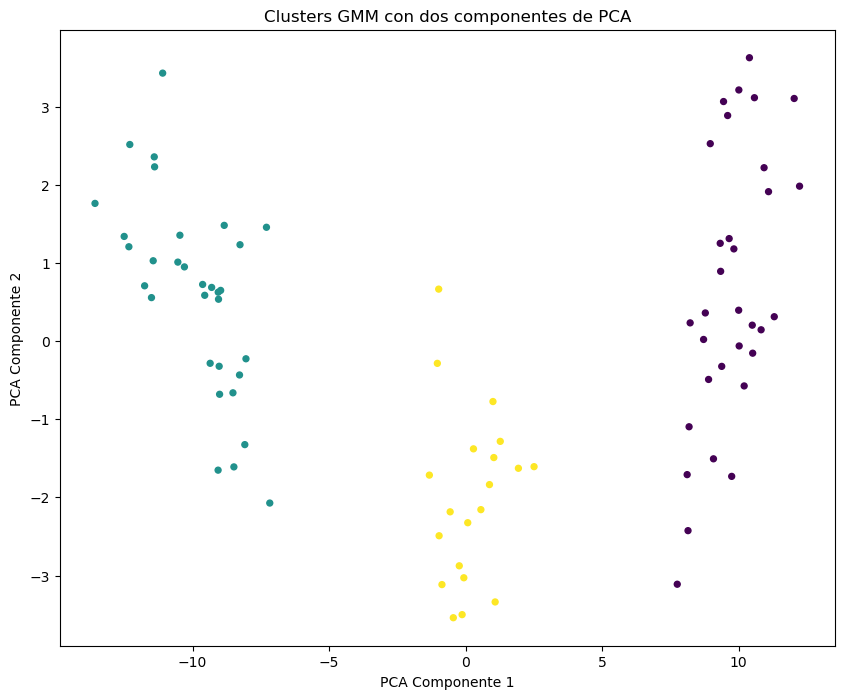

In [19]:


# Ploteamos los clusters

plt.figure(figsize=(10, 8))
plt.scatter(df_pca_shopping.values[:, 0], df_pca_shopping.values[:, 1], c= df_pca_shopping.values[:,2], cmap='viridis', s=18)

plt.xlabel('PCA Componente 1')
plt.ylabel('PCA Componente 2')
plt.title('Clusters GMM con dos componentes de PCA')
plt.show()


In [20]:
df.head()

,Bread,Milk,Eggs,Beer,Chips
Customer,,,,,
c001,12,10,8,0,1
c002,10,8,7,1,0
c003,11,9,6,0,1
c004,1,2,1,10,8
c005,0,1,2,12,10


In [21]:
df.describe()

,Bread,Milk,Eggs,Beer,Chips
count,84.000000,84.000000,84.000000,84.000000,84.000000
mean,6.297619,5.297619,4.142857,5.333333,4.630952
std,4.976523,3.731274,3.089597,4.616193,3.892470
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,1.000000,1.000000,1.000000
50%,5.000000,5.000000,4.000000,4.000000,4.000000
75%,11.000000,9.000000,7.000000,10.000000,8.000000
max,15.000000,12.000000,10.000000,14.000000,12.000000


In [22]:
min_df = df.describe().iloc[3,:]
max_df = df.describe().iloc[-1,:]
min_df

Bread    0.0
Milk     0.0
Eggs     0.0
Beer     0.0
Chips    0.0
Name: min, dtype: float64

In [23]:
max_df

Bread    15.0
Milk     12.0
Eggs     10.0
Beer     14.0
Chips    12.0
Name: max, dtype: float64

In [26]:
# Cree un nuevo cliente con la misma estructura del dataframe original

import random

nuevo_dato = np.array([[random.randint(min_df.iloc[i], max_df.iloc[i]) for i in range(len(max_df))]])
nuevo_dato

array([[ 7, 11,  1,  8,  0]])

In [27]:
# Prediga el cluster al que pertenece este nuevo cliente
new_data_scale = scale.transform(nuevo_dato)
new_data_scale

c:\Users\x\.conda\envs\aaa_curso_2026\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[ 0.14198659,  1.53744543, -1.02334806,  0.58114617, -1.19686642]])

In [28]:
predict_cluster = gmm_shopping.predict(new_data_scale)
predict_cluster

c:\Users\x\.conda\envs\aaa_curso_2026\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GaussianMixture was fitted with feature names
  warnings.warn(


array([1], dtype=int64)

In [29]:
predict_proba_cluster = gmm_shopping.predict_proba(new_data_scale)
predict_proba_cluster

c:\Users\x\.conda\envs\aaa_curso_2026\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GaussianMixture was fitted with feature names
  warnings.warn(


array([[1.06529466e-13, 9.99999999e-01, 6.02173623e-10]])

In [ ]:
# En función al resultado, cree una recomendación a este nuevo cliente


**2.-**  Obtenga un modelo de clustering para el dataset `healthcare_dataset.csv` para obtener una agrupación de pacientes sanitarios mediante GMM: Los hospitales a menudo necesitan agrupar a pacientes con características similares para: identificar pacientes de alto riesgo, personalizar planes de tratamiento, optimizar la asignación de recursos y mejorar la gestión sanitaria.

In [ ]:
#Cargamos el dataset


In [ ]:
# Escalamiento y selección de características (¿Qué hacemos si tenemos columnas categoricas y numéricas y queremos utilizarlas en el clustering?)

In [ ]:
# Entrene el modelo por GMM utilice métricas para saber cuantos componentes elegir y cree una coluna para assignar el cluster


In [ ]:
# Cree un nuevo paciente con algunos valores en base a las columnas elegidas 


In [ ]:
# Muestre graficas de sus resultados